In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('insurance.csv')

In [3]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
data.head(5)#read top 5

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


EDA


In [5]:
data.shape #1338 rows and 7 columns
    

(1338, 7)

In [6]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
data.isnull().sum()#count of null values in each columns

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

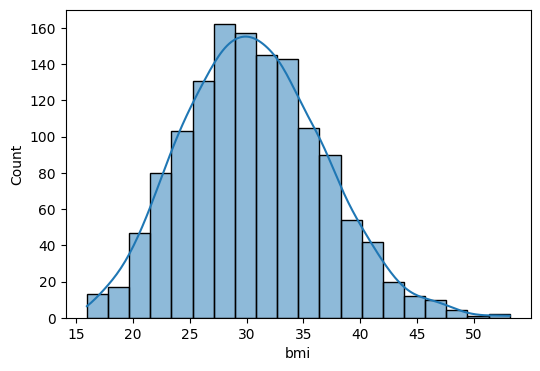

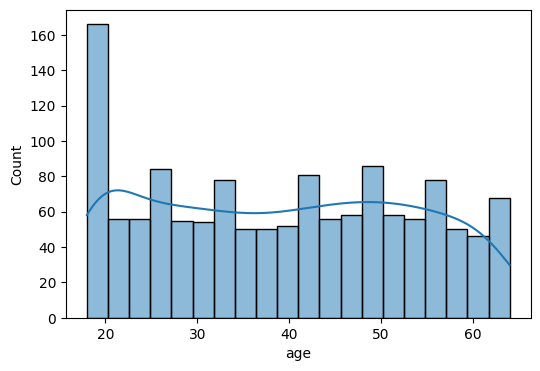

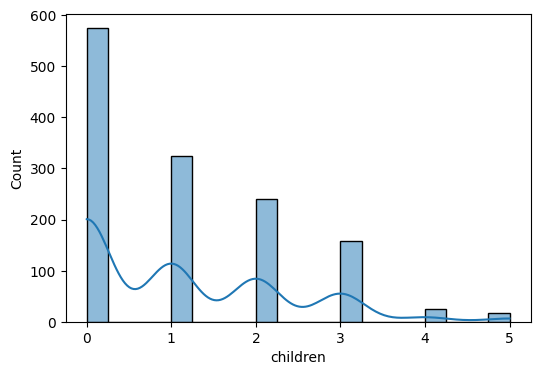

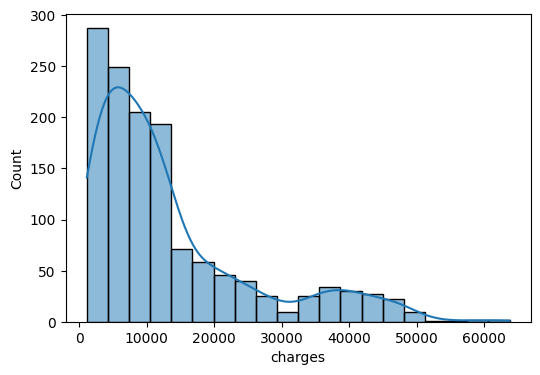

In [10]:
numeric_columns = ['bmi','age','children', 'charges']
for col in numeric_columns :
    plt.figure(figsize = (6,4))
    sns.histplot(data[col],kde = True, bins = 20)

<Axes: xlabel='children', ylabel='count'>

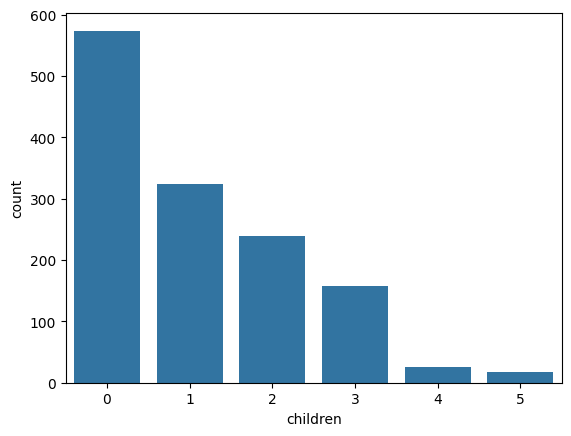

In [11]:
#children's hostogram doesnt give much insight, so we will use the countplot for it
sns.countplot(x = data['children'])

<Axes: xlabel='sex', ylabel='count'>

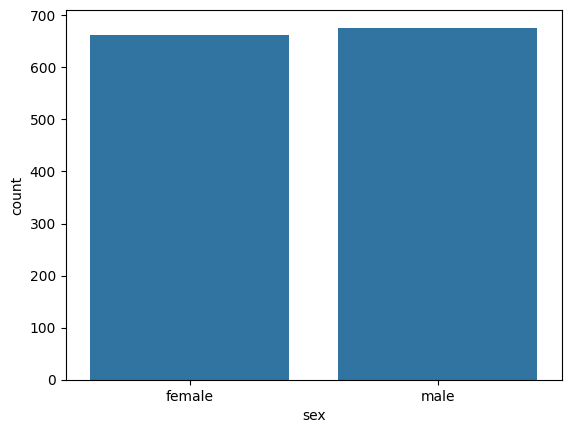

In [12]:
sns.countplot(x= data['sex'])
#they are almost equally distributed

<Axes: xlabel='smoker', ylabel='count'>

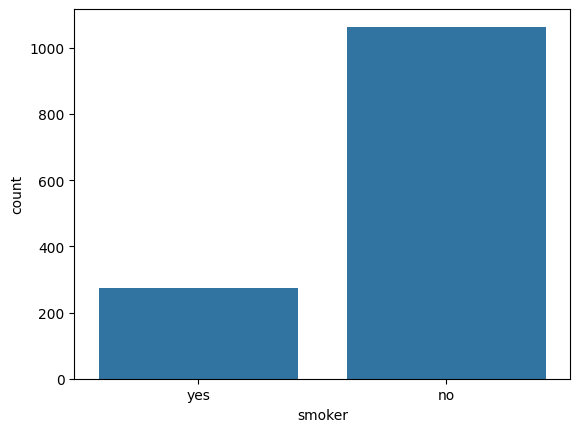

In [13]:
sns.countplot(x = data['smoker'])

### Box Plots

A **Box Plot** visually summarizes the distribution of a numerical column through quartiles. It is the best tool for identifying outliers and comparing data across different categories.

**The Anatomy of a Box Plot:**
* **Median (Middle Line):** The exact middle value of the dataset.
* **The Box (IQR):** Contains the middle 50% of the data (from the 25th percentile to the 75th percentile).
* **The Whiskers:** Represent the typical range of the data, extending to 1.5x the size of the box.
* **The Dots:** Data points falling outside the whiskers are mathematically considered **outliers**.

 Syntax:
`sns.boxplot(x='Categorical_Column', y='Numerical_Column', data=dataframe)`

<Axes: xlabel='smoker', ylabel='charges'>

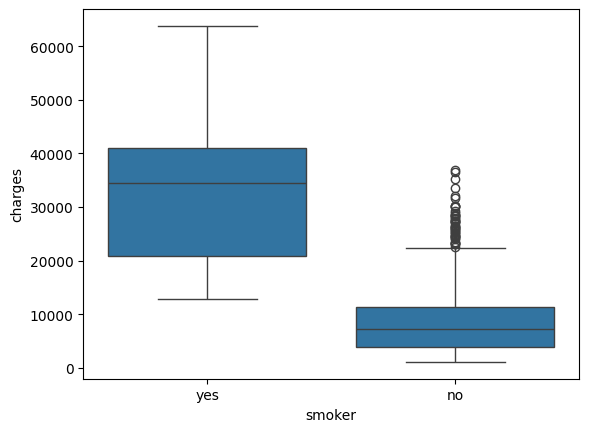

In [14]:
#for the smoker vs non smoker distribution
sns.boxplot(x= data['smoker'], y = data['charges'])

#huge gap in the two boxes show that smoking is a very important factor for the insurance charges.

the cheapest bill for a smoker is 13000 roughly which is higher than what the 75% of non smokers pay.

many dots over the nonsmoker box signify the people who pay higher insurance charges than what their group people do, for them not smoking is not the only deciding factor, but may be they are older or have abnormal bmi or some other medical cause.

non smokers insurance range is low and predicable whereas for smokers tha range is very high and also unpredictable.

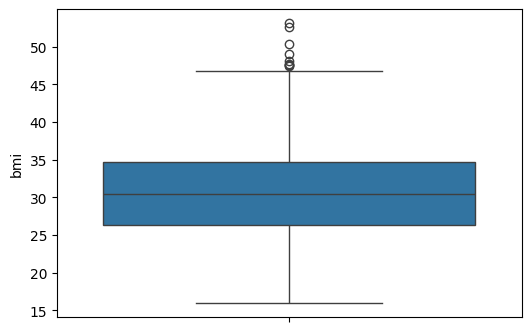

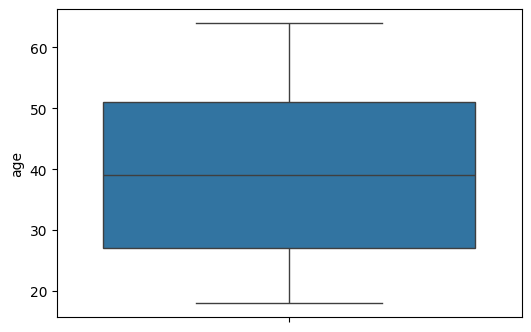

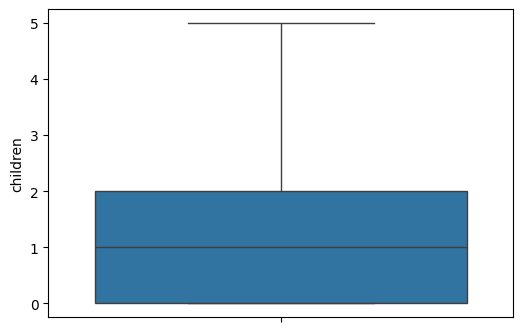

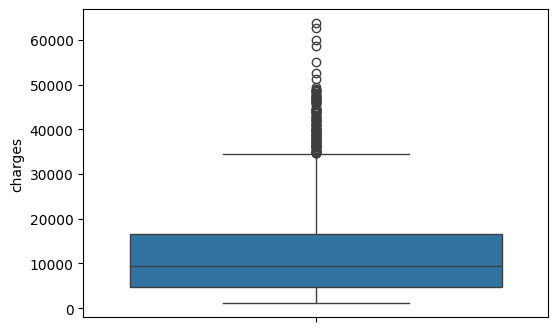

In [15]:
for col in numeric_columns :
    plt.figure(figsize = (6,4))
    sns.boxplot (  data[col])

### Correlation Heatmaps

A **Heatmap** is a two-dimensional graphical representation of data where individual values are represented by colors. In Exploratory Data Analysis (EDA), we use it to visualize the **correlation matrix**—the mathematical relationship between all numerical columns in a dataset.

**Why Do We Use It?**
1. **Identify Drivers:** To instantly see which features have the strongest mathematical impact on our target variable (e.g., seeing what drives up `charges`).
2. **Feature Selection:** To decide which variables are worth keeping for a machine learning model.
3. **Spot Multicollinearity:** To find out if two "independent" columns are actually telling us the exact same thing (e.g., `birth_year` and `age`), which can confuse and break machine learning algorithms.


<Axes: >

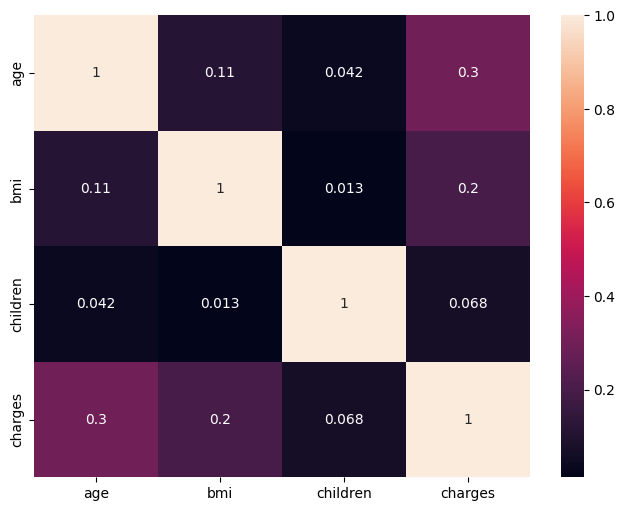

In [16]:
plt.figure(figsize = (8,6))
sns.heatmap(data.corr(numeric_only=True), annot = True)

we can see that the column children almost doesnt have any major correlation with any of the other numeric columns. while charges and age have a positive correlation. none have negative correlation.

## Data Cleaning
To prevent the "Garbage In, Garbage Out" problem. If you feed a machine learning algorithm broken or duplicate data, it will confidently learn broken patterns.

**Common Cleaning Tasks:**
1. **Removing Duplicates:** Dropping identical rows that can accidentally double-count and bias the model(using drop_duplicates).
2. **Handling Missing Values (NaN):** Either deleting rows with missing data, or "imputing" (filling) the blanks with a logical guess like the column's average or median(in this dataset we have no null values).
3. **Fixing Typos and Formats:** Ensuring data entry errors are standardized (e.g., changing "Femal" and "F" to "Female").

# 1. Identify and drop exact duplicate rows
df = df.drop_duplicates()

# 2. Check for missing values (NaN) across all columns
print(df.isnull().sum())

# 3. Handle missing values (Choose A or B)
# Option A: Drop any row that contains a missing value
df = df.dropna() 

# Option B: Fill missing values with the column's median (e.g., for the 'age' column)
df['age'] = df['age'].fillna(df['age'].median())

In [17]:
data_cleaned = data.copy()
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
data_cleaned.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
data.shape


(1338, 7)

In [20]:
#no null values, so we wont have to worry about it, we will delete the duplicate rows if any now
data_cleaned.drop_duplicates(inplace = True)
data_cleaned.shape

#one duplicate row has been removed

(1337, 7)

In [21]:
data_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [22]:
#we will see the unique values and their count to ensure that different terms are not used for same thing like male or Male or M
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

## Data Preprocessing

**We will first do Label Encoding**
Machine learning models are mathematical engines; they cannot read or understand text strings like "yes", "no", "male", or "female". **Label Encoding** is the process of converting these text-based categorical columns into machine-readable numbers.

In [23]:
#for the sex columne , male gets 0 and female gets 1
data_cleaned['sex'] = data_cleaned['sex'].map({"male": 0 , "female" : 1})

In [24]:

#the name sex is irrelevant so we will chnage the name to is_female
data_cleaned.rename(columns = {"sex" : "is_female"}, inplace = True)
data_cleaned.head()

,age,is_female,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
# we will do the same thing for smokers as well
#but we need to check the entries to ensure only two unique values exists
print(data_cleaned['smoker'].value_counts())
#now do label encoding
data_cleaned['smoker']=data_cleaned['smoker'].map({"yes":1,"no":0})
data_cleaned.head()

data_cleaned.rename(columns = {'smoker': 'is_smoker'},inplace = True)

smoker
no     1063
yes     274
Name: count, dtype: int64


### we will do One-Hot Encoding

**Why didn't we use Label Encoding for Regions?**
Label Encoding works perfectly for binary columns (like `sex` or `smoker`). 

However, the `region` column has four unique text categories (*southwest, southeast, northwest, northeast*). If we used Label Encoding, the algorithm would randomly assign them numbers like `0, 1, 2, and 3`. 

Because machine learning models are essentially giant math equations, the model would look at those numbers and incorrectly assume a **mathematical hierarchy**. It would think that Region 3 is "greater than" or "worth three times as much" as Region 1. Regions are geographical; they don't have a ranked mathematical value. Label Encoding them would completely bias the model.

**Solution: One-Hot Encoding**
Instead of assigning a ranked number, One-Hot Encoding pivots the data. It creates a brand new, separate column for *each* category. If a patient lives in the Northwest, the `region_northwest` column gets a `1`, and all other region columns get a `0`. 

In [26]:
data_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [27]:
data_cleaned= pd.get_dummies(data_cleaned, columns = ['region'], drop_first = True,dtype = int)
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


**`pd.get_dummies()`?**
used for **One-Hot Encoding**. It takes a single categorical column (like `region`) and explodes it into multiple new columns (one for each category), filling them with `1`s (True) and `0`s (False). This translates text into math for the machine learning model.

** `drop_first=True`?**
To avoid the **Dummy Variable Trap** (Multicollinearity). If you keep all the new columns, you feed the algorithm redundant information, which can break certain models (like Linear Regression). 

* **The Logic:** If we have three regions (North, South, East) and we drop "North", the model is still perfectly smart enough to know that if a patient is `0` for South and `0` for East, they **must** be from the North. Keeping the "North" column is mathematically useless!

### Feature Engineering 

**What is Feature Engineering?**
Feature engineering is the process of using human logic to create brand-new columns from existing data to give the machine learning model a clearer signal.

**The Strategy: "Binning" the BMI**
Right now, the model sees `bmi` as an endless sliding scale of numbers. It doesn't inherently know that a BMI of 24.9 is "healthy" and a BMI of 25.0 suddenly crosses the threshold into "overweight." We can help the model by mathematically grouping (binning) these continuous numbers into official medical categories, and then One-Hot Encoding those categories into 1s and 0s.

# 1. Define the medical thresholds for BMI
# 0 to 18.5 = underweight
# 18.5 to 25 = normal
# 25 to 30 = overweight
# 30 to inf = obese
bmi_edges = [0, 18.5, 25, 30, inf]
bmi_labels = ['underweight', 'normal', 'overweight', 'obese']

In [28]:
data_cleaned['bmi_category']= pd.cut(data_cleaned['bmi'], bins = [0,18.5,24.9,29.9, float('inf')], labels = ['Underweight','Normal','Overweight','Obese'])
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0,1,0,Obese
2,28,0,33.000,3,0,4449.46200,0,1,0,Obese
3,33,0,22.705,0,0,21984.47061,1,0,0,Normal
4,32,0,28.880,0,0,3866.85520,1,0,0,Overweight


In [29]:
#we will perform one hot encoding on bmi_category

data_cleaned = pd.get_dummies(data_cleaned,columns = ['bmi_category'],dtype  =  int, drop_first  = True)
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,0,1,0,1,0
1,18,0,33.770,1,0,1725.55230,0,1,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,1,0,0,0,1
3,33,0,22.705,0,0,21984.47061,1,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0,0,1,0


### Feature Scaling 

**What is Standardization?**
Standardization rescales our numerical columns so they all have a mean of `0` and a standard deviation of `1`. 

**Why do we need it?**
Machine learning models can be biased by large numbers. If we don't scale our data, the algorithm might assume a column with larger numbers is inherently more important than a column with smaller numbers. Scaling puts all features on a level playing field.

**The Formula (Z-Score):**
$$Z = \frac{x - \mu}{\sigma}$$

Important for model training :
### ✂️ Train/Test Split & Preventing Data Leakage

**What is it?**
Before teaching our machine learning model, we must split our `data_final` into a **Training Set** (80% of the data used for learning) and a **Testing Set** (20% of the data hidden away to evaluate real-world performance).

**Why do we split BEFORE scaling? (Data Leakage)**
We must split the data before applying `StandardScaler`. If we scale the whole dataset first, the mathematical calculations (like the mean) will include the test data. This "leaks" information from the final exam into the training process, artificially inflating our accuracy. 

By splitting first, we ensure our test data remains completely unseen and pure.

from sklearn.model_selection import train_test_split

# 1. Separate the Target (y) from the Features (X)
# We drop 'charges' from X, and make it our isolated y variable
X = data_final.drop(columns=['charges'])
y = data_final['charges']

# 2. Perform the Split (80% Train, 20% Test)
# random_state=42 ensures we get the exact same random shuffle every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Best Practice Scaling
# scaler.fit_transform(X_train)  <-- Learns the math from the training data only
# scaler.transform(X_test)       <-- Applies that exact math to the unseen test data

In [30]:
# from sklearn.preprocessing import StandardScaler
# cols = ['bmi','children','age']
# scaler = StandardScaler()
# data_cleaned[cols] = scaler.fit_transform(data_cleaned[cols])
# data_cleaned.head()

# MOVED: Scaling is done AFTER train-test split to prevent data leakage.
# See the 'Train-Test Split & Scaling' section below.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------------------------
# 1. Drop columns that should NOT go into model
# -------------------------------------------
# charges_bin was created from charges itself — leakage if kept in X
# bmi is kept (raw) but we also have bmi_category — both can stay for now
cols_to_drop = ['charges']
X = data_cleaned.drop(columns = cols_to_drop)
Y = data_cleaned['charges']

In [32]:
# -------------------------------------------
# 2. Split FIRST — before any scaling
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,      # 20% goes to test set
    random_state=42     # fixes the random shuffle so results are reproducible
)

In [33]:
# -------------------------------------------
# 3. Scale AFTER split — fit ONLY on train
# -------------------------------------------
numeric_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

# .fit_transform on train: learns μ and σ from train rows, then scales them
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# .transform on test: uses the SAME μ and σ learned from train, just applies it
# does NOT re-learn anything from test rows
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])   

### Pearson Correlation with SciPy

While Pandas gives us the correlation score, we use `scipy.stats` to get the **P-value**. This allows us to mathematically prove that the relationship we found is real, and not just a coincidence of our specific sample size.

* **Correlation ($r$):** The strength and direction of the relationship (-1 to 1).
* **P-value:** The probability this happened by chance. We want this to be less than **0.05** (which means we are 95% confident the relationship is real).

## Let's test our strongest feature (smoker) against our target (charges)
r_score, p_value = pearsonr(data_cleaned['smoker'], data_cleaned['charges'])

## Let's test our weakest feature (children) against charges
r_score_child, p_value_child = pearsonr(data_cleaned['children'], data_cleaned['charges'])

In [34]:
from scipy.stats import pearsonr
data_cleaned.columns
#we want to check every feature against the charges and see its correlation with charges, so we can drop some columns if they are not related to charges

selected_features = ['age', 'is_female', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']

correlations = {feature : pearsonr(data_cleaned[feature], data_cleaned['charges'])[0]
for feature in selected_features}
# Convert the dictionary to a Pandas Series and sort it highest to lowest
corr_series = pd.Series(correlations).sort_values(ascending=False)
corr_series

is_smoker                  0.787234
age                        0.298308
bmi                        0.198401
bmi_category_Obese         0.197659
region_southeast           0.073578
children                   0.067389
region_northwest          -0.038695
region_southwest          -0.043637
is_female                 -0.058044
bmi_category_Normal       -0.105655
bmi_category_Overweight   -0.118279
dtype: float64

In [35]:
#insights : is_smoker is the main driving factor of the charges variable    

### The Chi-Square Test

When dealing with continuous numbers, we use the Pearson Correlation. However, when we want to mathematically prove if two **text/categorical** columns are related (e.g., *Does Gender affect Smoking Status?*), we use the **Chi-Square Test of Independence ($\chi^2$)**.

#### 1. The Contingency Table (Observed Reality)
Before doing any math, we organize our data into a **Contingency Table** (or Crosstab). This is simply a grid that counts exactly how many rows fall into each overlapping bucket (e.g., counting exactly how many *Male Smokers* versus *Female Smokers* exist in our dataset).

#### 2. The Expected Theory
The Chi-Square test then asks a theoretical question: *"If these two columns had absolutely nothing to do with each other, what **should** these numbers look like?"* It calculates an "Expected" table based on pure random chance.

#### 3. The Math ($\chi^2$)
The test mathematically compares our **Observed** reality against the **Expected** theory using this formula for every cell in the grid:

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

It subtracts the Expected count from the Observed count, squares it, and adds them all up. A massive final score means our real data is wildly different from random chance. 

#### 4. The Final Verdict (P-Value)
The test translates that final score into a **P-value**, which gives us our definitive answer:
* **P-value < 0.05:** The difference is too big to be random luck. The two categories are mathematically **Linked / Dependent**.
* **P-value > 0.05:** The difference is just random noise. The two categories are completely **Independent**.

###  Advanced Binning: `pd.qcut` (Quantiles)

Instead of manually guessing where to cut the data, `pd.qcut()` mathematically divides the data into buckets that contain an equal number of rows.

**Python Syntax:**

# Let's create 4 equal-sized buckets (Quartiles) for our charges
# The parameter 'q' stands for the number of quantiles
data_cleaned['charges_bin'] = pd.qcut(data_cleaned['charges'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Let's prove it worked by counting how many patients are in each bucket
print(data_cleaned['charge_quartiles'].value_counts())

In [36]:
from scipy.stats import chi2_contingency
categorical_features = ['is_female', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']
alpha = 0.05
data_cleaned['charges_bin'] = pd.qcut(data_cleaned['charges'],q = 4, labels = False) 
chi2_results ={}
for col in categorical_features :
       contingency_table = pd.crosstab(data_cleaned[col],data_cleaned['charges_bin'])
       chi2_stat,p_val,_,_ = chi2_contingency(contingency_table)
       #the function gives out 4 values includinf dof and expected table , we will throw away the last two results

       decision = 'Reject Null (keep feature)' if p_val<alpha else 'Accept Null(drop feature)'
       chi2_results[col] = {'chi2_statistic':chi2_stat,'p_val': p_val,  'Decision':decision }

In [37]:
chi2_df  = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by = 'p_val')
chi2_df

,chi2_statistic,p_val,Decision
is_smoker,848.219178,0.0,Reject Null (keep feature)
region_southeast,15.998167,0.001135,Reject Null (keep feature)
is_female,10.258784,0.01649,Reject Null (keep feature)
bmi_category_Obese,7.654464,0.05372,Accept Null(drop feature)
region_southwest,5.091893,0.165191,Accept Null(drop feature)
bmi_category_Normal,4.263673,0.234364,Accept Null(drop feature)
bmi_category_Overweight,4.201575,0.240504,Accept Null(drop feature)
region_northwest,1.13424,0.768815,Accept Null(drop feature)


In [38]:
data_final = data_cleaned[['is_smoker', 'age','is_female', 'bmi','children','charges','region_southeast','bmi_category_Obese']]
data_final.head()

,is_smoker,age,is_female,bmi,children,charges,region_southeast,bmi_category_Obese
0,1,19,1,27.900,0,16884.92400,0,0
1,0,18,0,33.770,1,1725.55230,1,1
2,0,28,0,33.000,3,4449.46200,1,1
3,0,33,0,22.705,0,21984.47061,0,0
4,0,32,0,28.880,0,3866.85520,0,0


In [39]:
data


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
